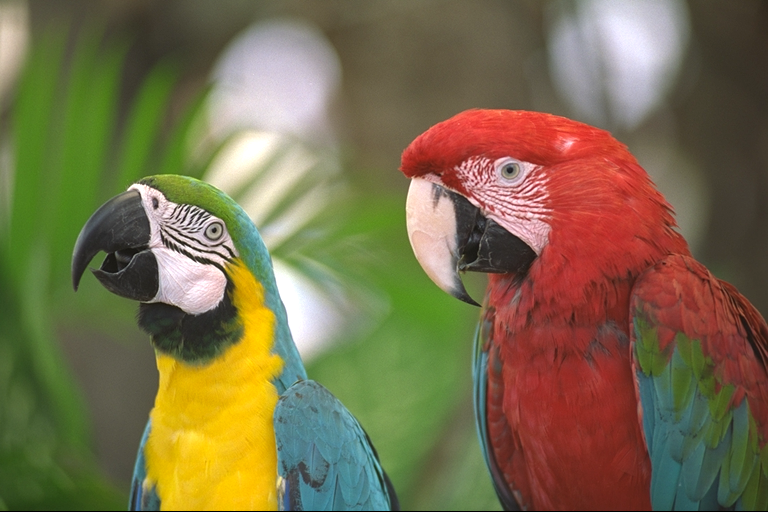

In [105]:
from PIL import Image
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/bittubiral/DT-and-K-Means-Clustering/main/kodim2.png"

img = Image.open(BytesIO(requests.get(url).content))
img

In [106]:
!git clone https://github.com/bittubiral/DT-and-K-Means-Clustering.git


fatal: destination path 'DT-and-K-Means-Clustering' already exists and is not an empty directory.


(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

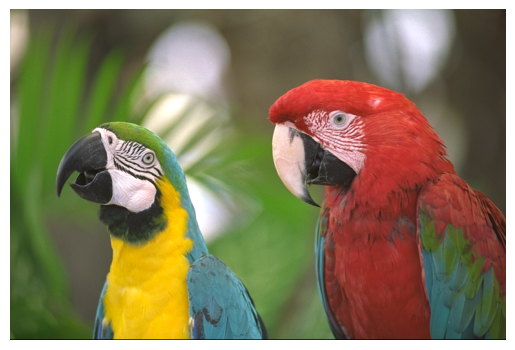

In [107]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("DT-and-K-Means-Clustering/kodim2.png")

plt.imshow(img)
plt.axis("off")

In [108]:
import numpy as np
train_img = np.array(img)

print(train_img.shape)

(512, 768, 3)


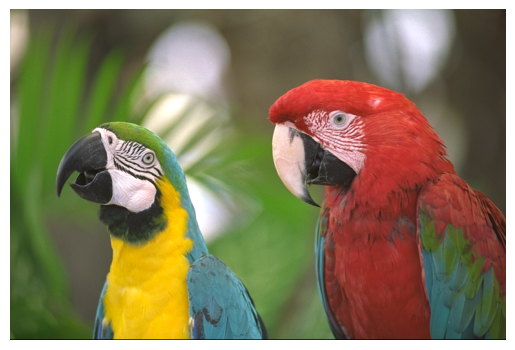

In [109]:
plt.imshow(train_img)
plt.axis("off")
plt.show()

In [110]:
pixels = train_img.reshape(-1, 3)

print(pixels.shape)

(393216, 3)


In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pixels_scaled = scaler.fit_transform(pixels)

In [112]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(pixels_scaled)

    wcss.append(km.inertia_)

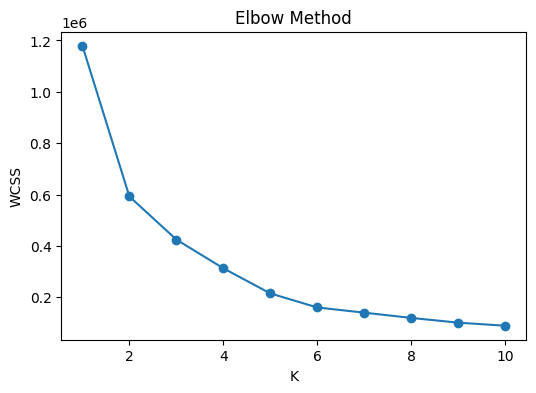

In [113]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [114]:

optimal_k = 16

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

kmeans.fit(pixels_scaled)

KMeans(n_clusters=16, random_state=42)

In [115]:
import joblib

joblib.dump(kmeans, "color_quantizer.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [116]:
from google.colab import files

files.download("color_quantizer.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [117]:
!rm -rf DT-and-K-Means-Clustering
!git clone https://github.com/bittubiral/DT-and-K-Means-Clustering.git

Cloning into 'DT-and-K-Means-Clustering'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 608.40 KiB | 5.53 MiB/s, done.


In [118]:
!ls DT-and-K-Means-Clustering

custom_img.jpeg  kodim2.png


In [119]:
custom = Image.open(
    "DT-and-K-Means-Clustering/custom_img.jpeg"
).convert("RGB")

custom_img = np.array(custom)

print(custom_img.shape)

(1200, 1600, 3)


In [120]:
custom_pixels = custom_img.reshape(-1, 3)

In [121]:
import joblib

kmeans = joblib.load("color_quantizer.pkl")
scaler = joblib.load("scaler.pkl")

In [122]:
custom_scaled = scaler.transform(custom_pixels)

In [123]:
labels = kmeans.predict(custom_scaled)

In [124]:
centers_scaled = kmeans.cluster_centers_
centers_scaled

array([[ 1.31929361, -0.84912208, -0.34815684],
       [-0.85842864, -0.39646171, -0.55822139],
       [ 1.70279895,  1.83132335,  2.36460858],
       [ 1.9824518 ,  1.54400895, -1.20430436],
       [ 0.11108926,  0.38785545,  0.54542852],
       [ 1.1237987 ,  1.32402344,  1.7874176 ],
       [-1.34280229, -1.35347798, -0.79453747],
       [ 0.15301987, -1.19096084, -0.64095549],
       [-0.1892435 ,  0.62843948, -0.05979623],
       [-0.55935721,  0.61776305,  1.34970981],
       [-0.6147334 ,  0.29285986, -0.63694535],
       [-0.39469007, -0.2895227 , -0.08668583],
       [ 2.10580103,  2.44080569,  2.9898461 ],
       [-0.97529446, -0.96658139, -0.53407712],
       [-1.01707629, -0.25176583,  0.34921861],
       [ 0.59648535,  0.86543318,  1.14922385]])

In [125]:
centers_rgb = scaler.inverse_transform(
    centers_scaled
)

In [126]:
quantized_pixels = centers_rgb[labels]

quantized_pixels = np.clip(
    quantized_pixels,
    0,
    255
).astype("uint8")

In [127]:
quantized_image = quantized_pixels.reshape(
    custom_img.shape
)

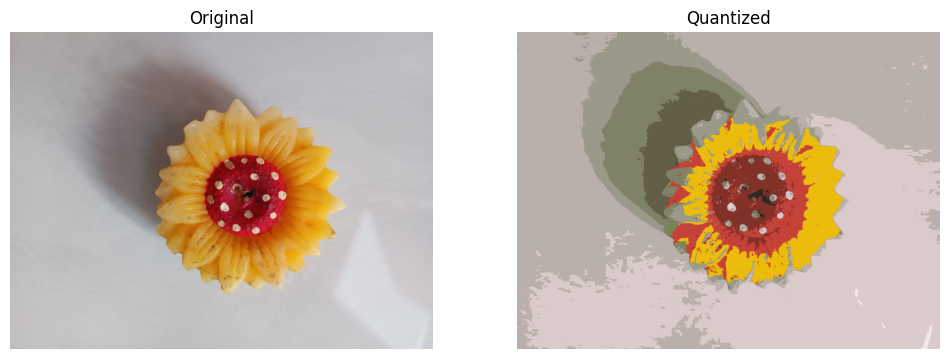

In [128]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(custom_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(quantized_image)
plt.title("Quantized")
plt.axis("off")

plt.show()

In [129]:
labels = kmeans.predict(custom_scaled)
labels

array([5, 5, 5, ..., 2, 2, 2], dtype=int32)

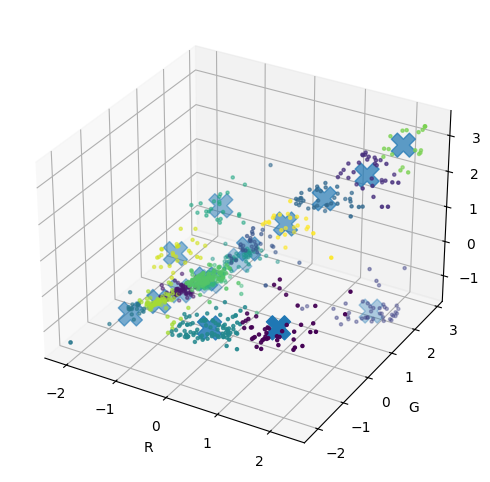

In [130]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

sample_pixels = pixels_scaled[::500]  # sample for speed
sample_labels = kmeans.predict(sample_pixels)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample_pixels[:,0],
    sample_pixels[:,1],
    sample_pixels[:,2],
    c=sample_labels,
    s=5
)

centers = kmeans.cluster_centers_

ax.scatter(
    centers[:,0],
    centers[:,1],
    centers[:,2],
    marker='X',
    s=300
)

ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')

plt.show()

In [131]:
import pandas as pd

sample_pixels = custom_pixels[:10]

sample_scaled = scaler.transform(sample_pixels)

sample_clusters = kmeans.predict(sample_scaled)

results = pd.DataFrame(
    sample_pixels,
    columns=["R","G","B"]
)

results["Cluster_ID"] = sample_clusters

results

,R,G,B,Cluster_ID
0,170,161,162,5
1,170,161,162,5
2,170,161,162,5
3,170,161,162,5
4,170,161,162,5
5,170,161,162,5
6,170,161,162,5
7,170,161,162,5
8,170,161,162,5
9,170,161,162,5


In [132]:
centroids_rgb = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centroids_rgb.astype(int))

#Cluster 0 represents dark blue tones found in deep background regions.
#Cluster 1 contains bright sky-blue colors to open sky areas.
#Cluster 2 captures green vegetation tones
#Cluster 3 represents light neutral colors in highlights and reflective surfaces.

[[197  66  57]
 [ 72  89  45]
 [219 202 202]
 [235 188  11]
 [128 129 105]
 [186 176 171]
 [ 44  40  33]
 [130  49  41]
 [110 141  72]
 [ 89 140 148]
 [ 86 124  41]
 [ 98  94  71]
 [242 233 236]
 [ 65  60  47]
 [ 63  96  94]
 [155 153 137]]
